# Assignment Day 33 - Time Series Forecasting

Case Study: Analisis Transaksi Harian E-Commerce dan Forecasting 1 Bulan ke Depan

**Nama:** Ghalib Abyan  
**Batch:** 43  
**Program:** Data Science & AI Bootcamp (Dibimbing)  
**Studi kasus:** Permintaan Tribe Growth untuk analisis transaksi harian dan forecasting sebagai dasar strategi bisnis

---

**Link github:** https://github.com/ghalibabyan/learn-time-series-forecasting.git

---

**Catatan:**
1. Metadata di guidance (Row ID, Segment, Profit, Discount, dll) **tidak sama** dengan file CSV yang diberikan. Data aktual hanya 6 kolom: `Order ID, Product, Quantity Ordered, Price Each, Order Date, Purchase Address`. Semua analisis memakai kolom yang benar-benar ada.
2. Tidak ada kolom **Discount** dan **biaya lain**, jadi GMV dihitung sebagai `Quantity Ordered x Price Each`. Ini nilai transaksi yang dibayarkan sesuai harga di data.
3. Tidak ada kolom **visitor**. Proksi yang dipakai: jumlah **alamat pembelian unik per hari**. Konsekuensinya dibahas di bagian I.
4. Kota yang dipakai adalah gabungan `City (State)` karena ada nama kota yang sama di state berbeda (contoh Portland di OR dan ME).

# A. Setup dan Memuat Data

## A.1 Import library

In [ ]:
# Library bawaan Python
import glob                                # mencari file berdasarkan pola nama
import warnings                            # mengatur pesan peringatan
from itertools import combinations         # membuat semua pasangan produk dalam satu order
from collections import Counter            # menghitung frekuensi pasangan produk

# Library data dan visualisasi
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Library statistik dan forecasting
from statsmodels.tsa.seasonal import seasonal_decompose          # decomposition trend/seasonal/residual
from statsmodels.tsa.stattools import adfuller                   # uji stasioneritas
from statsmodels.tsa.statespace.sarimax import SARIMAX           # model SARIMA
from statsmodels.tsa.holtwinters import ExponentialSmoothing     # model ETS / Holt-Winters

warnings.filterwarnings('ignore')          # sembunyikan warning konvergensi agar output rapi
pd.options.display.float_format = '{:,.2f}'.format   # format angka desimal 2 digit
plt.rcParams['figure.dpi'] = 100

## A.2 Memuat 12 file CSV bulanan

In [2]:
import glob
import pandas as pd

# folder tempat CSV berada (di Colab: folder upload atau path Google Drive)
DATA_DIR = (
    "/content/drive/MyDrive/"
    "Bootcamp Data Science & AI ML 2026/"
    "Assignment/"
    "Assignment Day 33 - Time Series Forecasting/"
    "Assignment Day 33_Time Series Forecasting_Ghalib Abyan/"
    "Data 12 Bulan (CSV)"
)

# glob mencari semua file yang cocok pola, sorted agar urutannya konsisten
files = sorted(glob.glob(f'{DATA_DIR}/sales_data_*.csv'))
print(f'Ditemukan {len(files)} file:')
for f in files:
    print('  -', f)

# Baca tiap file lalu tumpuk jadi satu DataFrame
df_raw = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)
print(f'\nUkuran data mentah: {df_raw.shape[0]:,} baris x {df_raw.shape[1]} kolom')
df_raw.head()

Ditemukan 12 file:
  - /content/drive/MyDrive/Bootcamp Data Science & AI ML 2026/Assignment/Assignment Day 33 - Time Series Forecasting/Assignment Day 33_Time Series Forecasting_Ghalib Abyan/Data 12 Bulan (CSV)/sales_data_april_2019.csv
  - /content/drive/MyDrive/Bootcamp Data Science & AI ML 2026/Assignment/Assignment Day 33 - Time Series Forecasting/Assignment Day 33_Time Series Forecasting_Ghalib Abyan/Data 12 Bulan (CSV)/sales_data_august_2019.csv
  - /content/drive/MyDrive/Bootcamp Data Science & AI ML 2026/Assignment/Assignment Day 33 - Time Series Forecasting/Assignment Day 33_Time Series Forecasting_Ghalib Abyan/Data 12 Bulan (CSV)/sales_data_december_2019.csv
  - /content/drive/MyDrive/Bootcamp Data Science & AI ML 2026/Assignment/Assignment Day 33 - Time Series Forecasting/Assignment Day 33_Time Series Forecasting_Ghalib Abyan/Data 12 Bulan (CSV)/sales_data_february_2019.csv
  - /content/drive/MyDrive/Bootcamp Data Science & AI ML 2026/Assignment/Assignment Day 33 - Time Seri

,Order ID,Product,Quantity Ordered,Price Each,Order Date,Purchase Address
0,176558,USB-C Charging Cable,2,11.95,04/19/19 08:46,"917 1st St, Dallas, TX 75001"
1,NaN,NaN,NaN,NaN,NaN,NaN
2,176559,Bose SoundSport Headphones,1,99.99,04/07/19 22:30,"682 Chestnut St, Boston, MA 02215"
3,176560,Google Phone,1,600,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"
4,176560,Wired Headphones,1,11.99,04/12/19 14:38,"669 Spruce St, Los Angeles, CA 90001"


#### Interpretasi

1. Ke-12 file bulanan (Januari sampai Desember 2019) berhasil terbaca dan digabung menjadi 186.850 baris dengan 6 kolom.
2. Kolom yang tersedia hanya Order ID, Product, Quantity Ordered, Price Each, Order Date, dan Purchase Address. Tidak ada kolom Discount, Profit, Segment, maupun visitor seperti yang tertulis di metadata guidance, jadi definisi GMV dan visitor perlu asumsi (lihat catatan di awal notebook).
3. Baris ke-2 pada contoh di atas sudah memperlihatkan baris kosong total (semua NaN), tanda awal bahwa data perlu dibersihkan.

# B. Eksplorasi dan Pembersihan Data

**Langkah 1 dan 2 guidance:** memahami struktur data, mengecek data hilang dan anomali, lalu transformasi agar layak untuk analisis time series.

## B.1 Struktur data

In [3]:
df_raw.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 186850 entries, 0 to 186849
Data columns (total 6 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   Order ID          186305 non-null  object
 1   Product           186305 non-null  object
 2   Quantity Ordered  186305 non-null  object
 3   Price Each        186305 non-null  object
 4   Order Date        186305 non-null  object
 5   Purchase Address  186305 non-null  object
dtypes: object(6)
memory usage: 8.6+ MB


#### Interpretasi

1. Seluruh 6 kolom bertipe `str` (teks), termasuk `Quantity Ordered`, `Price Each`, dan `Order Date`. Angka dan tanggal belum bisa dihitung sebelum dikonversi.
2. Non-null count hanya 186.305 dari 186.850 baris, artinya ada 545 baris yang kosong.

## B.2 Identifikasi baris kotor

In [4]:
# 1. Baris header yang ikut terbawa saat CSV digabung (isi kolom Order ID = teks 'Order ID')
mask_header = df_raw['Order ID'] == 'Order ID'
# 2. Baris yang seluruh kolomnya kosong
mask_empty = df_raw.isna().all(axis=1)
# 3. Baris duplikat persis
mask_dup = df_raw.duplicated()

print(f'Baris header nyasar : {mask_header.sum():,}')
print(f'Baris kosong total  : {mask_empty.sum():,}')
print(f'Duplikat persis     : {mask_dup.sum():,} (sudah termasuk duplikat dari header dan baris kosong)')
print(f'Missing value per kolom:')
print(df_raw.isna().sum())

Baris header nyasar : 355
Baris kosong total  : 545
Duplikat persis     : 1,162 (sudah termasuk duplikat dari header dan baris kosong)
Missing value per kolom:
Order ID            545
Product             545
Quantity Ordered    545
Price Each          545
Order Date          545
Purchase Address    545
dtype: int64


#### Interpretasi

1. Ada 355 baris header nyasar. Ini terjadi karena header tiap file CSV ikut terbawa saat 12 file digabung, dan inilah penyebab kolom angka terbaca sebagai teks.
2. Ada 545 baris kosong total. Angka ini sama dengan jumlah missing value di setiap kolom, jadi tidak ada missing value parsial. Barisnya kosong seluruhnya atau terisi seluruhnya.
3. Duplikat persis 1.162 baris, tetapi sebagian besar merupakan duplikat dari header dan baris kosong itu sendiri (355 dan 545 baris yang identik satu sama lain). Duplikat yang murni data transaksi baru terlihat setelah header dan baris kosong dibuang, dan dihitung pada langkah berikutnya.

## B.3 Pembersihan dan konversi tipe data

In [5]:
df = df_raw.copy()
n0 = len(df)

# Urutan penting: buang baris kotor DULU, baru konversi tipe data
df = df[df['Order ID'] != 'Order ID']       # buang header nyasar
df = df.dropna(how='all')                   # buang baris kosong total
n_sebelum_dup = len(df)
df = df.drop_duplicates()                   # buang duplikat persis
print(f'Duplikat persis yang tersisa setelah header dan baris kosong dibuang: {n_sebelum_dup - len(df):,}')

# Konversi tipe data
df['Quantity Ordered'] = pd.to_numeric(df['Quantity Ordered'], errors='coerce')
df['Price Each']       = pd.to_numeric(df['Price Each'], errors='coerce')
df['Order Date']       = pd.to_datetime(df['Order Date'], format='%m/%d/%y %H:%M', errors='coerce')

# Cek apakah ada nilai yang gagal dikonversi
print('\nNilai kosong setelah konversi:')
print(df[['Order ID', 'Quantity Ordered', 'Price Each', 'Order Date']].isna().sum())

print(f'\nBaris awal  : {n0:,}')
print(f'Baris akhir : {len(df):,}')
print(f'Terbuang    : {n0 - len(df):,} ({(n0 - len(df)) / n0 * 100:.2f}%)')

Duplikat persis yang tersisa setelah header dan baris kosong dibuang: 264

Nilai kosong setelah konversi:
Order ID            0
Quantity Ordered    0
Price Each          0
Order Date          0
dtype: int64

Baris awal  : 186,850
Baris akhir : 185,686
Terbuang    : 1,164 (0.62%)


#### Interpretasi

1. Setelah header dan baris kosong dibuang, masih tersisa 264 duplikat persis (Order ID, produk, jumlah, harga, waktu, dan alamat yang sama). Baris ini dibuang karena kemungkinan besar input ganda. Risikonya kecil karena hanya 264 baris.
2. Total baris terbuang 1.164 atau 0,62% dari data. Angkanya di bawah 1%, jadi pembersihan tidak menghilangkan porsi data yang material.
3. Setelah konversi, tidak ada nilai kosong pada Order ID, Quantity Ordered, Price Each, dan Order Date. Format tanggal `%m/%d/%y %H:%M` cocok untuk seluruh baris.

## B.4 Membuat kolom turunan

In [6]:
# Revenue per baris = jumlah unit x harga satuan (dipakai sebagai GMV)
df['Revenue'] = df['Quantity Ordered'] * df['Price Each']

# Pecah alamat: "944 Walnut St, Boston, MA 02215" -> jalan, kota, state+kodepos
parts = df['Purchase Address'].str.split(',')
df['City']      = parts.str[1].str.strip()
df['State']     = parts.str[2].str.strip().str[:2]
df['CityState'] = df['City'] + ' (' + df['State'] + ')'

# Kolom waktu
df['Date']  = df['Order Date'].dt.normalize()     # tanggal saja
df['Hour']  = df['Order Date'].dt.hour            # jam 0-23
df['Month'] = df['Order Date'].dt.to_period('M')  # periode bulanan

df[['Order ID', 'Product', 'Quantity Ordered', 'Price Each', 'Revenue', 'CityState', 'Order Date', 'Hour']].head()

,Order ID,Product,Quantity Ordered,Price Each,Revenue,CityState,Order Date,Hour
0,176558,USB-C Charging Cable,2,11.95,23.90,Dallas (TX),2019-04-19 08:46:00,8
2,176559,Bose SoundSport Headphones,1,99.99,99.99,Boston (MA),2019-04-07 22:30:00,22
3,176560,Google Phone,1,600.00,600.00,Los Angeles (CA),2019-04-12 14:38:00,14
4,176560,Wired Headphones,1,11.99,11.99,Los Angeles (CA),2019-04-12 14:38:00,14
5,176561,Wired Headphones,1,11.99,11.99,Los Angeles (CA),2019-04-30 09:27:00,9


## B.5 Cek anomali: satuan order dan hari parsial

In [7]:
# Satu Order ID bisa terdiri dari beberapa baris (order multi-produk)
print(f"Jumlah BARIS      : {len(df):,}")
print(f"Jumlah ORDER unik : {df['Order ID'].nunique():,}")
print(f"Selisih           : {len(df) - df['Order ID'].nunique():,} baris berasal dari order multi-produk")

# Apakah satu Order ID pernah tercatat di lebih dari satu tanggal?
print(f"Order ID yang muncul di >1 tanggal: {(df.groupby('Order ID')['Date'].nunique() > 1).sum()}")

# Cek rentang waktu dan hari dengan order paling sedikit
print(f"\nRentang waktu: {df['Order Date'].min()} s/d {df['Order Date'].max()}")
harian_cek = df.groupby('Date').agg(orders=('Order ID', 'nunique'), gmv=('Revenue', 'sum'))
print('\n5 hari dengan order tersedikit:')
print(harian_cek.nsmallest(5, 'orders'))

Jumlah BARIS      : 185,686
Jumlah ORDER unik : 178,437
Selisih           : 7,249 baris berasal dari order multi-produk
Order ID yang muncul di >1 tanggal: 0

Rentang waktu: 2019-01-01 03:07:00 s/d 2020-01-01 05:13:00

5 hari dengan order tersedikit:
            orders       gmv
Date                        
2020-01-01      31   8670.29
2019-01-14     265  50078.53
2019-01-31     265  62383.13
2019-01-23     269  57572.45
2019-01-08     271  56100.52


#### Interpretasi

1. Ada 185.686 baris tetapi hanya 178.437 order unik. Selisih 7.249 baris berasal dari order yang berisi lebih dari satu produk. Konsekuensinya, jumlah order harus dihitung dengan `nunique` pada Order ID, bukan jumlah baris. Kalau memakai jumlah baris, order akan terhitung berlebih sekitar 4%.
2. Tidak ada Order ID yang muncul di lebih dari satu tanggal, jadi satu order selalu jatuh di satu hari dan agregasi harian aman.
3. File Desember ternyata memuat 31 order tanggal 1 Januari 2020 (sampai pukul 05.13). Ini bukan anomali transaksi, tetapi hari yang baru terekam sebagian.

In [8]:
# Hari parsial = hari dengan order < 25% dari median harian
median_harian = harian_cek['orders'].median()
ambang = median_harian * 0.25
hari_parsial = harian_cek[harian_cek['orders'] < ambang].index
print(f'Median order/hari  : {median_harian:.0f}')
print(f'Ambang hari parsial: {ambang:.0f}')
print(f'Hari parsial       : {[str(d.date()) for d in hari_parsial]}')

# Buang hari parsial agar tidak terbaca sebagai "penurunan" palsu
df = df[~df['Date'].isin(hari_parsial)]
print(f'\nData final: {df["Date"].min().date()} s/d {df["Date"].max().date()} '
      f'({df["Date"].nunique()} hari, {len(df):,} baris, {df["Order ID"].nunique():,} order)')

Median order/hari  : 457
Ambang hari parsial: 114
Hari parsial       : ['2020-01-01']

Data final: 2019-01-01 s/d 2019-12-31 (365 hari, 185,652 baris, 178,406 order)


#### Interpretasi

1. Median order per hari adalah 457, sehingga ambang hari parsial 114 order. Hanya 1 Januari 2020 yang berada di bawah ambang (31 order), dan tanggal itu dibuang.
2. Kalau hari parsial ini dibiarkan, deret waktu akan menampilkan penurunan palsu di titik paling akhir, dan model forecasting akan belajar dari penurunan yang sebenarnya tidak ada.
3. Data final mencakup tepat 365 hari (1 Januari sampai 31 Desember 2019) tanpa tanggal bolong, dengan 178.406 order unik.

# C. Perhitungan Awal Tahun 2019

**P1.** Hitunglah total revenue, jumlah order, dan jumlah barang yang terjual sepanjang tahun 2019. Hitung juga rata-rata jumlah barang per transaksi dan rata-rata spending per transaksi.

In [9]:
total_revenue = df['Revenue'].sum()
jumlah_order  = df['Order ID'].nunique()          # order UNIK, bukan jumlah baris
jumlah_barang = df['Quantity Ordered'].sum()

# Rata-rata per transaksi harus diagregasi per Order ID DULU
per_order = df.groupby('Order ID').agg(qty=('Quantity Ordered', 'sum'), rev=('Revenue', 'sum'))
avg_item  = per_order['qty'].mean()
avg_spend = per_order['rev'].mean()

print('=' * 58)
print('  RINGKASAN PERFORMA 2019')
print('=' * 58)
print(f'  Total revenue (GMV)      : ${total_revenue:>14,.2f}')
print(f'  Jumlah order             : {jumlah_order:>15,}')
print(f'  Jumlah barang terjual    : {jumlah_barang:>15,}')
print(f'  Rata-rata item/transaksi : {avg_item:>15.2f}')
print(f'  Rata-rata spending/trx   : ${avg_spend:>14,.2f}')
print('=' * 58)

  RINGKASAN PERFORMA 2019
  Total revenue (GMV)      : $ 34,456,867.65
  Jumlah order             :         178,406
  Jumlah barang terjual    :         208,771
  Rata-rata item/transaksi :            1.17
  Rata-rata spending/trx   : $        193.14


#### Interpretasi

1. Total revenue 2019 adalah $34.456.867,65 dari 178.406 order dan 208.771 barang terjual.

2. Rata-rata barang per transaksi 1,17. Artinya hampir semua order hanya berisi satu unit, sehingga ruang untuk cross-sell masih besar.
3. Rata-rata spending per transaksi $193,14. Angka ini jauh lebih tinggi dari harga kebanyakan aksesoris, sehingga nilai per order banyak ditentukan oleh sedikit order berisi produk mahal (laptop, ponsel, monitor).
4. Rata-rata dihitung setelah data diagregasi per Order ID. Kalau dihitung langsung per baris, hasilnya akan meleset karena order multi-produk terpecah menjadi beberapa baris.

# D. Agregasi Harian, Mingguan, Bulanan

**P2.** Hitunglah jumlah order dan GMV dengan rentang waktu harian, mingguan, dan bulanan.

**P3 (catatan).** GMV dihitung dari total spending customer. Karena data tidak memiliki kolom diskon maupun biaya lain, GMV = `Quantity Ordered x Price Each`.

In [10]:
d = df.set_index('Order Date')
agg = {'orders': ('Order ID', 'nunique'), 'gmv': ('Revenue', 'sum')}

harian   = d.resample('D').agg(**agg)     # harian
mingguan = d.resample('W').agg(**agg)     # mingguan (minggu berakhir hari Minggu)
bulanan  = d.resample('ME').agg(**agg)    # bulanan (akhir bulan)

# Jumlah hari berisi data per periode, untuk membandingkan periode yang panjangnya beda
mingguan['hari'] = d.resample('W')['Order ID'].apply(lambda s: s.index.normalize().nunique())
bulanan['hari']  = d.resample('ME')['Order ID'].apply(lambda s: s.index.normalize().nunique())
mingguan['gmv_per_hari'] = mingguan['gmv'] / mingguan['hari']
bulanan['gmv_per_hari']  = bulanan['gmv'] / bulanan['hari']
bulanan['order_per_hari'] = bulanan['orders'] / bulanan['hari']

print('--- HARIAN ---')
print(harian.head(10))
print(f"\nRata-rata harian: {harian['orders'].mean():.0f} order, ${harian['gmv'].mean():,.0f} GMV")
print(f"Hari tertinggi  : {harian['orders'].idxmax().date()} ({harian['orders'].max()} order)")
print(f"Hari terendah   : {harian['orders'].idxmin().date()} ({harian['orders'].min()} order)")

print('\n--- MINGGUAN ---')
print(mingguan.round(0).to_string())

print('\n--- BULANAN ---')
bulanan.index = bulanan.index.strftime('%Y-%m')
print(bulanan.round(0).to_string())

--- HARIAN ---
            orders       gmv
Order Date                  
2019-01-01     287  65681.94
2019-01-02     308  70663.20
2019-01-03     286  47046.20
2019-01-04     282  62000.22
2019-01-05     301  46524.63
2019-01-06     279  52762.54
2019-01-07     296  53676.42
2019-01-08     271  56100.52
2019-01-09     308  55153.13
2019-01-10     316  56660.92

Rata-rata harian: 489 order, $94,402 GMV
Hari tertinggi  : 2019-12-17 (843 order)
Hari terendah   : 2019-01-14 (265 order)

--- MINGGUAN ---
            orders        gmv  hari  gmv_per_hari
Order Date                                       
2019-01-06    1743   344679.0     6       57446.0
2019-01-13    2104   409389.0     7       58484.0
2019-01-20    2104   394921.0     7       56417.0
2019-01-27    2134   426020.0     7       60860.0
2019-02-03    2381   459571.0     7       65653.0
2019-02-10    2832   565300.0     7       80757.0
2019-02-17    2926   568199.0     7       81171.0
2019-02-24    2880   535208.0     7       764

#### Interpretasi

1. Rata-rata harian 489 order dan $94.402 GMV. Hari tertinggi 17 Desember 2019 (843 order) dan terendah 14 Januari 2019 (265 order), rasio sekitar 3,2 kali.

2. Pola bulanan sangat tidak rata. Order per hari 299 (Januari), naik ke 584 (April), turun ke 370 dan 373 (Agustus dan September), naik ke 627 (Oktober), dan puncak 774 (Desember). Desember menghasilkan GMV $4,61 juta, sekitar 2,5 kali Januari ($1,81 juta).

3. Total bulanan mentah dipengaruhi jumlah hari (Februari 28 hari, bulan lain 30 sampai 31 hari). Karena itu kolom `gmv_per_hari` dan `order_per_hari` dipakai untuk membandingkan bulan secara adil.

4. Data mingguan punya dua minggu parsial. Minggu pertama hanya 6 hari (1 sampai 6 Januari) dan minggu terakhir hanya 2 hari (30 sampai 31 Desember). Keduanya perlu dibaca lewat `gmv_per_hari`, bukan total minggu.

5. Data mingguan memperlihatkan pola yang tidak terlihat di harian, yaitu lompatan tingkat penjualan yang terjadi tepat di awal bulan tertentu, misalnya minggu yang berakhir 6 Oktober (4.099 order) dibanding minggu sebelumnya (2.622 order).

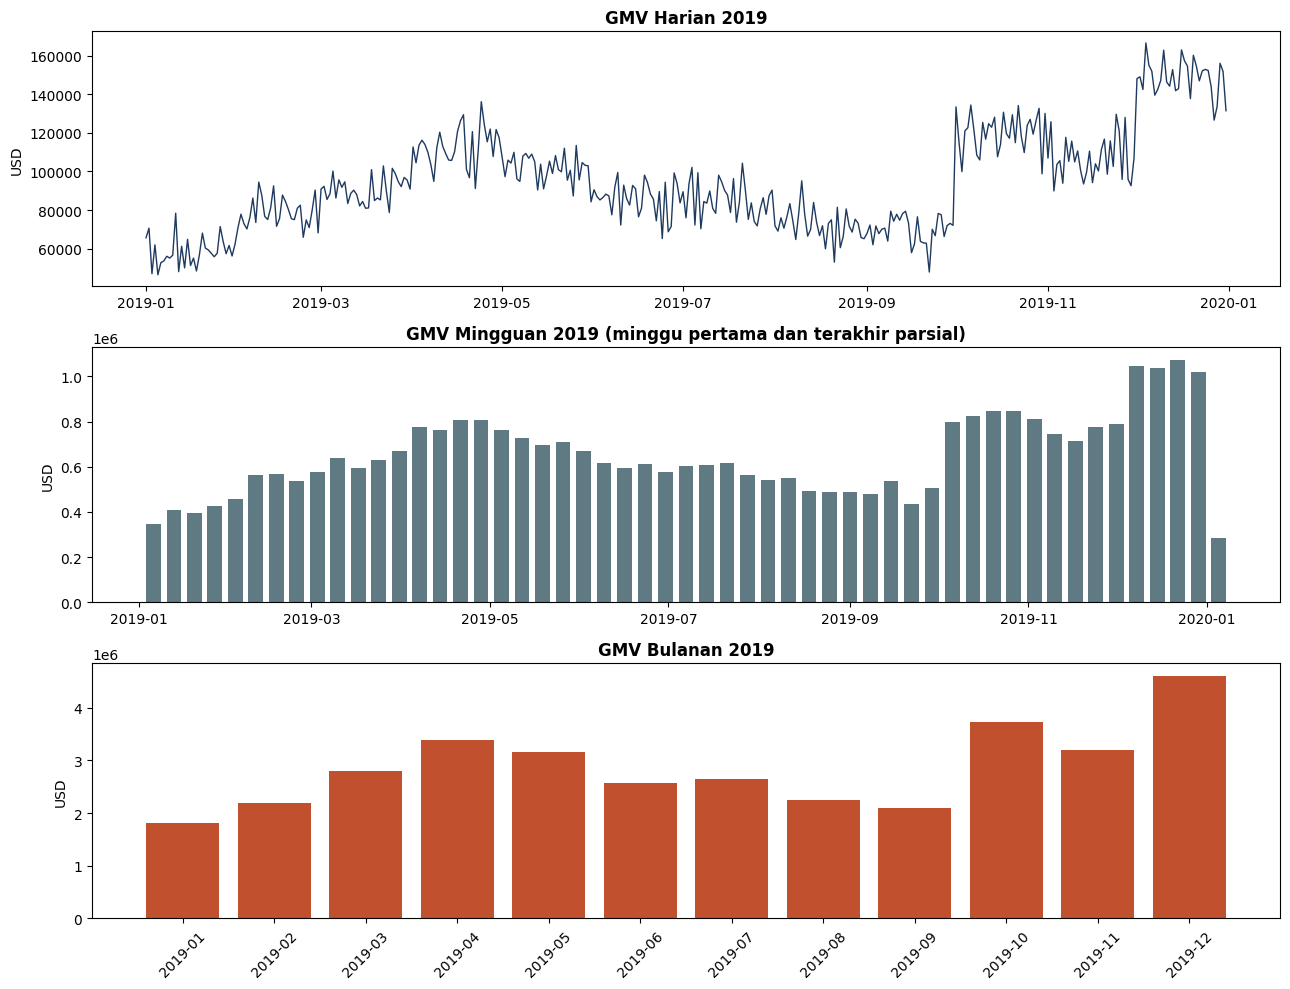

In [15]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(3, 1, figsize=(13, 10))
ax[0].plot(harian.index, harian['gmv'], lw=1, color='#1F3A5F')
ax[0].set_title('GMV Harian 2019', fontweight='bold'); ax[0].set_ylabel('USD')
ax[1].bar(mingguan.index, mingguan['gmv'], width=5, color='#5F7A82')
ax[1].set_title('GMV Mingguan 2019 (minggu pertama dan terakhir parsial)', fontweight='bold'); ax[1].set_ylabel('USD')
ax[2].bar(bulanan.index, bulanan['gmv'], color='#C1502E')
ax[2].set_title('GMV Bulanan 2019', fontweight='bold'); ax[2].set_ylabel('USD')
plt.setp(ax[2].get_xticklabels(), rotation=45)
plt.tight_layout(); plt.show()

#### Interpretasi

1. Grafik harian terlihat berisik tetapi pola besarnya jelas. Ada beberapa lompatan tingkat (level shift) di awal bulan tertentu, yaitu Februari, April, Oktober, dan Desember, lalu tingkat itu bertahan sepanjang bulan.
2. Grafik mingguan dan bulanan menampilkan pola ini lebih bersih. Puncak ada di April, Oktober, dan Desember, dan lembah ada di Januari, Agustus, dan September.
3. Untuk kebutuhan strategis (anggaran, target), tampilan bulanan paling mudah dibaca. Untuk kebutuhan operasional (staf, stok), tampilan harian dan mingguan lebih relevan.

# E. Top Produk dan Peluang Bundling

**P4.** Tim marketing ingin mem-bundling produk terlaris. Identifikasi top 10 produk dengan revenue terbesar dalam 3 bulan terakhir (Oktober sampai Desember 2019) dan produk apa yang bisa di-bundling.

In [16]:
# 3 bulan terakhir = Oktober sampai Desember 2019
l3 = df[df['Date'] >= '2019-10-01']
print(f'Periode 3 bulan terakhir: {l3["Date"].min().date()} s/d {l3["Date"].max().date()}  ({l3["Order ID"].nunique():,} order)')

produk = l3.groupby('Product').agg(
    revenue=('Revenue', 'sum'),
    qty=('Quantity Ordered', 'sum'),
    orders=('Order ID', 'nunique')
)
produk['share_revenue_%'] = produk['revenue'] / produk['revenue'].sum() * 100
top10 = produk.nlargest(10, 'revenue')
print('\n--- TOP 10 PRODUK BERDASARKAN REVENUE (Okt-Des 2019) ---')
print(top10.round(1))
print(f"\nKontribusi top 10 terhadap revenue 3 bulan terakhir: {top10['share_revenue_%'].sum():.1f}%")

print('\n--- Pembanding: TOP 5 BERDASARKAN KUANTITAS ---')
print(produk.nlargest(5, 'qty')[['qty', 'revenue']].round(0))

Periode 3 bulan terakhir: 2019-10-01 s/d 2019-12-31  (60,299 order)

--- TOP 10 PRODUK BERDASARKAN REVENUE (Okt-Des 2019) ---
                              revenue   qty  orders  share_revenue_%
Product                                                             
Macbook Pro Laptop          2733600.0  1608    1608             23.7
iPhone                      1600900.0  2287    2285             13.9
ThinkPad Laptop             1371986.3  1372    1371             11.9
Google Phone                1082400.0  1804    1803              9.4
27in 4K Gaming Monitor       841988.4  2159    2154              7.3
Apple Airpods Headphones     787800.0  5252    5212              6.8
34in Ultrawide Monitor       786579.3  2070    2064              6.8
Flatscreen TV                493800.0  1646    1639              4.3
Bose SoundSport Headphones   453054.7  4531    4475              3.9
27in FHD Monitor             370325.3  2469    2456              3.2

Kontribusi top 10 terhadap revenue 3 bulan te

#### Interpretasi

1. Top 10 produk menyumbang 91,2% dari revenue Oktober sampai Desember 2019. Revenue sangat terkonsentrasi pada produk bernilai tinggi.

2. Macbook Pro Laptop di peringkat 1 dengan revenue $2,73 juta  atau  23,7% dari total, hanya dari 1.608 unit. iPhone kedua ($1,60 juta) dan ThinkPad Laptop ketiga ($1,37 juta).

3. Urutan berdasarkan kuantitas sangat berbeda. AAA Batteries (10.616 unit), AA Batteries (9.282), dan kabel USB-C dan Lightning mendominasi volume, tetapi revenue masing-masing kecil ($31 ribu  sampai  $117 ribu). Produk ini bukan penggerak revenue, tetapi cocok sebagai pelengkap paket.

4. Dua ukuran itu menjawab pertanyaan berbeda. Revenue menentukan produk yang perlu dilindungi ketersediaannya dan dipromosikan. Kuantitas menentukan produk yang menggerakkan traffic dan frekuensi belanja.

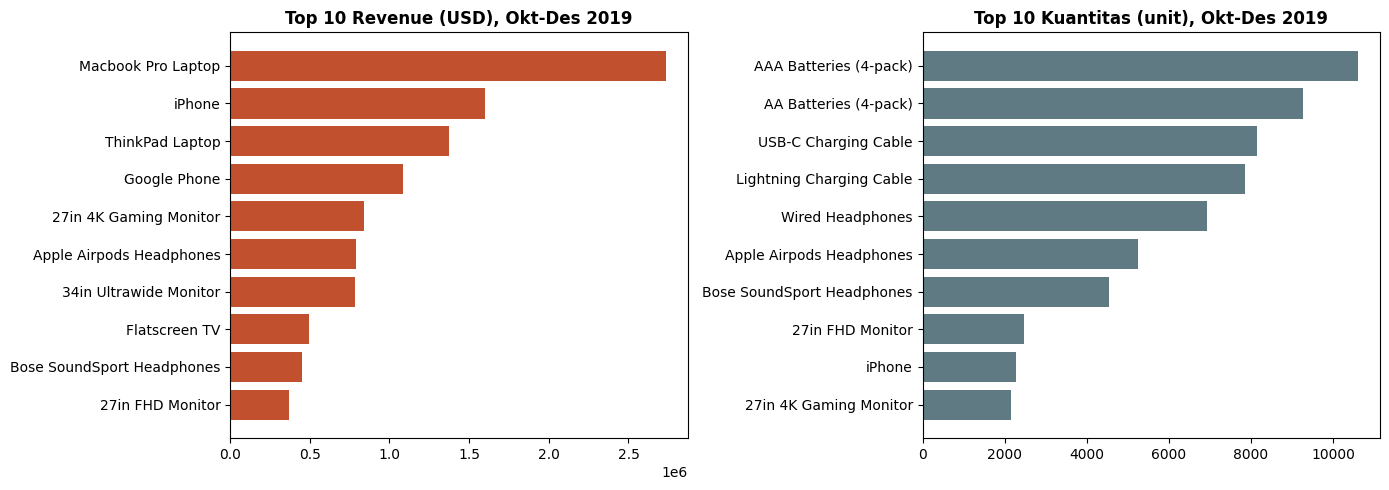

In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
t_rev = produk.nlargest(10, 'revenue'); t_qty = produk.nlargest(10, 'qty')
ax[0].barh(t_rev.index[::-1], t_rev['revenue'][::-1], color='#C1502E'); ax[0].set_title('Top 10 Revenue (USD), Okt-Des 2019', fontweight='bold')
ax[1].barh(t_qty.index[::-1], t_qty['qty'][::-1], color='#5F7A82');    ax[1].set_title('Top 10 Kuantitas (unit), Okt-Des 2019', fontweight='bold')
plt.tight_layout(); plt.show()

## E.1 Analisis bundling (market basket sederhana)

In [20]:
from collections import Counter
from itertools import combinations
import pandas as pd

# Hanya order multi-produk yang relevan untuk melihat produk apa yang dibeli bersamaan
multi = l3[l3['Order ID'].duplicated(keep=False)]
n_order_total = l3['Order ID'].nunique()
n_order_multi = multi['Order ID'].nunique()
print(f'Order multi-produk: {n_order_multi:,} dari {n_order_total:,} order ({n_order_multi / n_order_total * 100:.1f}%)')

pasangan = Counter()
for _, g in multi.groupby('Order ID'):
    for pair in combinations(sorted(set(g['Product'])), 2):
        pasangan[pair] += 1

# Hitung juga frekuensi tiap produk di seluruh order (untuk lift)
frek_produk = l3.groupby('Product')['Order ID'].nunique()

baris = []
for (a, b), n in pasangan.items():
    support  = n / n_order_total
    lift = support / ((frek_produk[a] / n_order_total) * (frek_produk[b] / n_order_total))
    baris.append({'Pasangan': f'{a} + {b}', 'Frekuensi': n, 'Support_%': support * 100, 'Lift': lift,
                  'Keduanya_Top10': (a in top10.index) and (b in top10.index)})
pair_df = pd.DataFrame(baris).sort_values('Frekuensi', ascending=False)

print('\n--- TOP 10 PASANGAN PRODUK PALING SERING DIBELI BERSAMAAN ---')
print(pair_df.head(10).round(2).to_string(index=False))
print('\n--- PASANGAN DI ANTARA TOP 10 REVENUE ---')
print(pair_df[pair_df['Keduanya_Top10']].head(5).round(2).to_string(index=False))

Order multi-produk: 2,299 dari 60,299 order (3.8%)

--- TOP 10 PASANGAN PRODUK PALING SERING DIBELI BERSAMAAN ---
                                   Pasangan  Frekuensi  Support_%  Lift  Keduanya_Top10
        Google Phone + USB-C Charging Cable        314       0.52  1.41           False
          Lightning Charging Cable + iPhone        307       0.51  1.10           False
                  Wired Headphones + iPhone        163       0.27  0.67           False
            Google Phone + Wired Headphones        155       0.26  0.81           False
          Apple Airpods Headphones + iPhone        132       0.22  0.67            True
     USB-C Charging Cable + Vareebadd Phone        130       0.22  1.58           False
  Bose SoundSport Headphones + Google Phone         81       0.13  0.61            True
    USB-C Charging Cable + Wired Headphones         74       0.12  0.09           False
         Vareebadd Phone + Wired Headphones         51       0.08  0.72           False
Lightn

#### Interpretasi

1. Hanya 3,8% order (2.299 dari 60.299) yang berisi lebih dari satu produk. Bukti pola belanja bersamaan memang tipis, sehingga hasil bundling di bawah ini perlu dibaca sebagai indikasi awal, bukan kesimpulan kuat.

2. Pasangan paling sering adalah Google Phone dan kabel USB-C (314 kali, lift 1,41) serta iPhone dan kabel Lightning (307 kali, lift 1,10). Lift di atas 1 berarti pasangan itu dibeli bersamaan lebih sering daripada kebetulan. Pasangan ini juga masuk akal secara fungsi karena kabel sesuai dengan colokan ponselnya. Vareebadd Phone dan kabel USB-C punya lift tertinggi (1,58) dengan frekuensi 130.

3. Di antara top 10 revenue, pasangan terbanyak adalah iPhone dan Apple Airpods (132 kali) serta Google Phone dan Bose SoundSport (81 kali). Namun lift keduanya di bawah 1 (0,67 dan 0,61). Artinya kombinasi ini tidak dibeli bersamaan lebih sering dari kebetulan, jadi frekuensinya tinggi hanya karena masing-masing produk memang populer.

4. Rekomendasi bundling yang paling kuat secara data adalah ponsel dengan kabel pengisi yang sesuai (Google Phone + USB-C, iPhone + Lightning, Vareebadd Phone + USB-C). Bundling iPhone dengan Airpods atau Google Phone dengan Bose masih layak dicoba sebagai eksperimen berbatas waktu, tetapi datanya belum mendukung sebagai bundling utama.

# F. Analisis Kota

**P5.** Identifikasi top 5 kota dengan order terbanyak dan top 5 kota dengan total dan rata-rata spending terbesar.

In [21]:
kota = df.groupby('CityState').agg(orders=('Order ID', 'nunique'), gmv=('Revenue', 'sum'))
kota['aov'] = kota['gmv'] / kota['orders']            # rata-rata spending per order
kota['share_gmv_%'] = kota['gmv'] / kota['gmv'].sum() * 100

print('--- TOP 5 KOTA: JUMLAH ORDER ---');           print(kota.nlargest(5, 'orders').round(2))
print('\n--- TOP 5 KOTA: TOTAL SPENDING (GMV) ---'); print(kota.nlargest(5, 'gmv').round(2))
print('\n--- TOP 5 KOTA: RATA-RATA SPENDING PER ORDER ---'); print(kota.nlargest(5, 'aov').round(2))
print(f"\nRentang AOV seluruh kota: ${kota['aov'].min():.2f} sampai ${kota['aov'].max():.2f}")
print(f"Jumlah kota: {len(kota)} | Kontribusi top 3 kota terhadap GMV: {kota.nlargest(3,'gmv')['share_gmv_%'].sum():.1f}%")

--- TOP 5 KOTA: JUMLAH ORDER ---
                    orders         gmv     aov  share_gmv_%
CityState                                                  
San Francisco (CA)   42887  8252258.67  192.42        23.95
Los Angeles (CA)     28497  5447304.29  191.15        15.81
New York City (NY)   23840  4660526.52  195.49        13.53
Boston (MA)          19088  3657300.76  191.60        10.61
Atlanta (GA)         14253  2794199.07  196.04         8.11

--- TOP 5 KOTA: TOTAL SPENDING (GMV) ---
                    orders         gmv     aov  share_gmv_%
CityState                                                  
San Francisco (CA)   42887  8252258.67  192.42        23.95
Los Angeles (CA)     28497  5447304.29  191.15        15.81
New York City (NY)   23840  4660526.52  195.49        13.53
Boston (MA)          19088  3657300.76  191.60        10.61
Atlanta (GA)         14253  2794199.07  196.04         8.11

--- TOP 5 KOTA: RATA-RATA SPENDING PER ORDER ---
                    orders         

#### Interpretasi

1. Top 5 kota berdasarkan order dan berdasarkan total GMV identik dan berurutan sama, yaitu San Francisco (42.887 order, $8,25 juta), Los Angeles  (28.497, $5,45 juta), New York City (23.840, $4,66 juta), Boston (19.088, $3,66 juta), dan Atlanta (14.253, $2,79 juta). Karena nilai per order hampir sama di semua kota, total GMV praktis mengikuti jumlah order.

2. San Francisco sendiri menyumbang 23,95% GMV dan tiga kota teratas 53,3%. Bisnis ini bergantung pada segelintir kota.

3. Top 5 berdasarkan rata-rata spending per order adalah Atlanta ($196,04), New York City ($195,49), Portland OR ($194,47), Seattle ($194,43), dan Dallas ($194,10). Namun rentang seluruh kota hanya $190,15 sampai $196,04 atau sekitar 3%. Selisih sekecil ini tidak cukup kuat untuk dijadikan dasar strategi. Perbedaan antar kota terutama soal volume, bukan nilai keranjang.

4. Data hanya memuat 10 kota, jadi kesimpulan tidak berlaku untuk pasar yang belum terlayani.

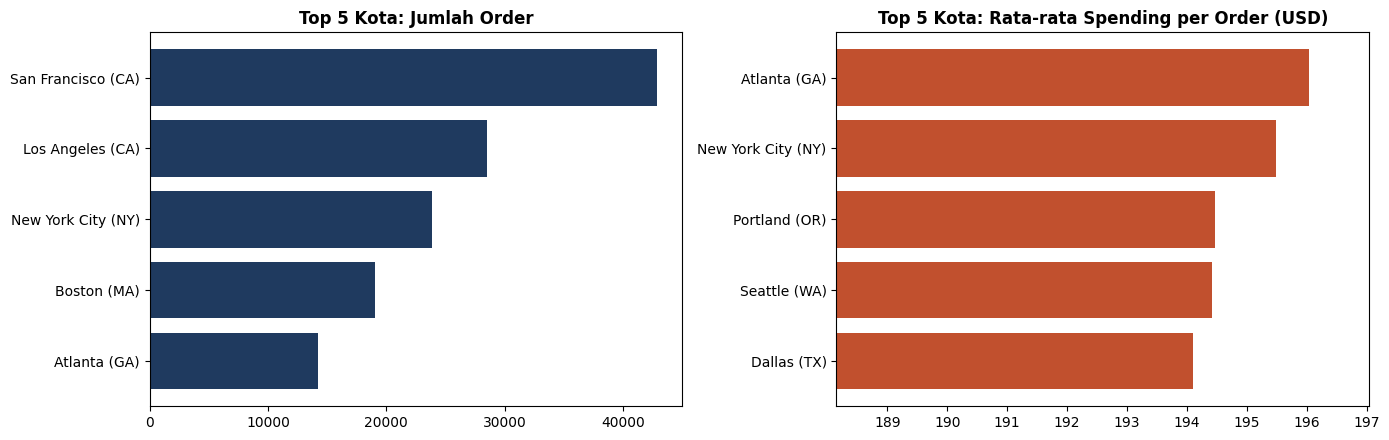

In [22]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
k1 = kota.nlargest(5, 'orders'); k2 = kota.nlargest(5, 'aov')
ax[0].barh(k1.index[::-1], k1['orders'][::-1], color='#1F3A5F'); ax[0].set_title('Top 5 Kota: Jumlah Order', fontweight='bold')
ax[1].barh(k2.index[::-1], k2['aov'][::-1], color='#C1502E'); ax[1].set_title('Top 5 Kota: Rata-rata Spending per Order (USD)', fontweight='bold')
ax[1].set_xlim(kota['aov'].min() - 2, kota['aov'].max() + 1)
plt.tight_layout(); plt.show()

# G. Rush Hour

**P6.** Analisis pada rentang jam berapa penjualan terjadi secara aktif (rush hour) agar marketing dapat merancang strategi.

5 jam teramai:
      orders         gmv
Hour                    
19     12377  2411971.14
12     12082  2314359.85
11     11882  2296619.84
20     11763  2280784.36
18     11761  2218374.01

3 jam tersepi:
      orders        gmv
Hour                   
3        801  144683.04
4        810  162281.15
2       1192  232574.51

Ambang rush hour (90% dari puncak): 11,139 order
Rush hour: 11.00-11.59, 12.00-12.59, 13.00-13.59, 18.00-18.59, 19.00-19.59, 20.00-20.59
Kontribusi jam rush terhadap total order: 40.1%


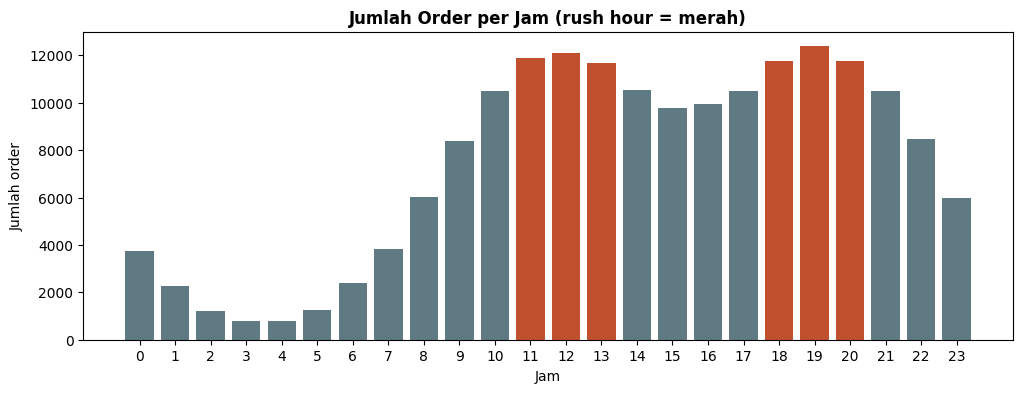

In [23]:
jam = df.groupby('Hour').agg(orders=('Order ID', 'nunique'), gmv=('Revenue', 'sum'))

# Definisi rush hour: jam dengan order >= 90% dari jam tersibuk
ambang_rush = jam['orders'].max() * 0.9
rush = sorted(jam[jam['orders'] >= ambang_rush].index.tolist())
print('5 jam teramai:'); print(jam.nlargest(5, 'orders'))
print('\n3 jam tersepi:'); print(jam.nsmallest(3, 'orders'))
print(f'\nAmbang rush hour (90% dari puncak): {ambang_rush:,.0f} order')
print('Rush hour: ' + ', '.join(f'{h:02d}.00-{h:02d}.59' for h in rush))
print(f"Kontribusi jam rush terhadap total order: {jam.loc[rush, 'orders'].sum() / jam['orders'].sum() * 100:.1f}%")

warna = ['#C1502E' if v >= ambang_rush else '#5F7A82' for v in jam['orders']]
plt.figure(figsize=(12, 4)); plt.bar(jam.index, jam['orders'], color=warna)
plt.title('Jumlah Order per Jam (rush hour = merah)', fontweight='bold')
plt.xlabel('Jam'); plt.ylabel('Jumlah order'); plt.xticks(range(24)); plt.show()

#### Interpretasi

1. Ada dua puncak harian. Puncak siang pada 11.00 sampai 13.59 dan puncak malam pada 18.00 sampai 20.59. Jam tersibuk adalah 19.00 (12.377 order), disusul 12.00 (12.082) dan 11.00 (11.882).

2. Enam jam rush hour itu (25% dari waktu satu hari) menampung 40,1% dari seluruh order, jadi konsentrasinya nyata.

3. Jam tersepi adalah 03.00 (801 order) dan 04.00 (810 order), sekitar 15 kali lebih sepi dari puncak.

4. Definisi rush hour di sini adalah jam dengan order minimal 90% dari jam tersibuk. Ambang ini pilihan analis, dan kalau diturunkan ke 80% jumlah jam yang masuk akan bertambah.

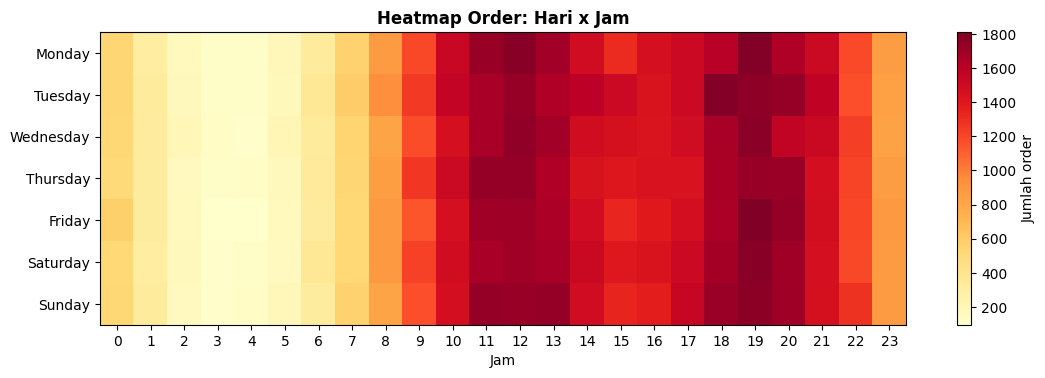

Rata-rata order per hari, menurut hari dalam minggu:
DayName
Monday       490.0
Tuesday      492.0
Wednesday    488.0
Thursday     488.0
Friday       485.0
Saturday     489.0
Sunday       490.0
dtype: float64


In [24]:
# Apakah pola jam berbeda antar hari dalam seminggu? Heatmap jam x hari
df['DayName'] = df['Order Date'].dt.day_name()
urut_hari = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
pivot = df.groupby(['DayName', 'Hour'])['Order ID'].nunique().unstack().reindex(urut_hari)

plt.figure(figsize=(13, 3.8))
plt.imshow(pivot.values, aspect='auto', cmap='YlOrRd')
plt.yticks(range(7), urut_hari); plt.xticks(range(24), range(24))
plt.colorbar(label='Jumlah order'); plt.title('Heatmap Order: Hari x Jam', fontweight='bold'); plt.xlabel('Jam')
plt.show()

hari_tot = df.groupby('DayName')['Order ID'].nunique().reindex(urut_hari)
n_hari = df.groupby('DayName')['Date'].nunique().reindex(urut_hari)
print('Rata-rata order per hari, menurut hari dalam minggu:')
print((hari_tot / n_hari).round(0))

#### Interpretasi

1. Heatmap memperlihatkan pola dua puncak yang sama di semua hari, tanpa perbedaan mencolok antar hari.
2. Rata-rata order per hari hampir sama untuk ketujuh hari (485 sampai 492). Tidak ada hari yang secara nyata lebih ramai, sehingga pemilihan hari untuk kampanye tidak akan banyak berpengaruh. Yang penting adalah jam tayangnya.
3. Ini berbeda dari pola e-commerce pada umumnya yang biasanya ramai di akhir pekan, jadi pola hari dalam minggu tidak boleh diasumsikan, harus dicek dari data.

# H. Analisis Tren dan Pola

Sebelum membangun model, perlu dipahami dulu trend, seasonality, dan stasioneritas data.

## H.1 Menyiapkan deret waktu harian

Periode     : 2019-01-01 s/d 2019-12-31 (365 hari)
Tanggal bolong: 0
Korelasi trx vs visitor (proksi): 1.0000
Selisih rata-rata trx - visitor : 0.36 per hari
         trx  visitor
count  365.0    365.0
mean   488.8    488.4
std    128.8    128.6
min    265.0    265.0
25%    391.0    391.0
50%    457.0    457.0
75%    575.0    574.0
max    843.0    842.0


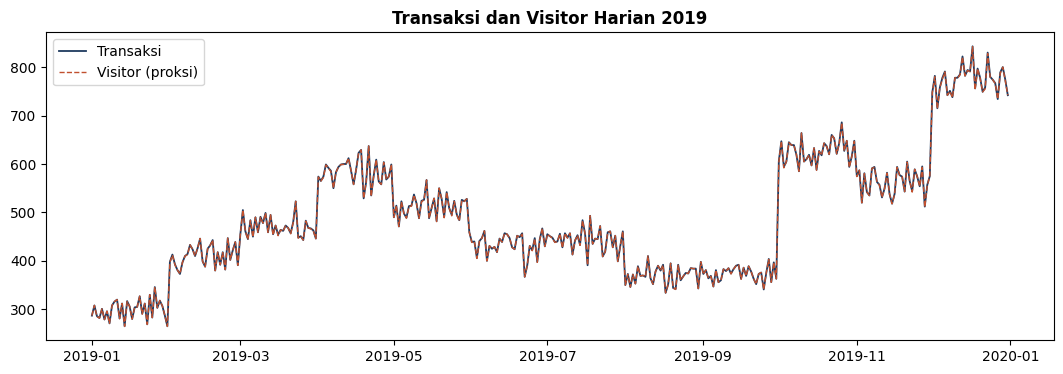

In [25]:
daily = df.groupby('Date').agg(
    trx=('Order ID', 'nunique'),              # jumlah transaksi
    visitor=('Purchase Address', 'nunique'),  # PROKSI visitor: alamat pembelian unik per hari
    gmv=('Revenue', 'sum')
).asfreq('D')                                 # pastikan setiap hari ada barisnya

print(f'Periode     : {daily.index.min().date()} s/d {daily.index.max().date()} ({len(daily)} hari)')
print(f'Tanggal bolong: {daily["trx"].isna().sum()}')
print(f'Korelasi trx vs visitor (proksi): {daily["trx"].corr(daily["visitor"]):.4f}')
print(f'Selisih rata-rata trx - visitor : {(daily["trx"] - daily["visitor"]).mean():.2f} per hari')
print(daily[['trx', 'visitor']].describe().round(1))

plt.figure(figsize=(13, 4))
plt.plot(daily.index, daily['trx'], lw=1.3, color='#1F3A5F', label='Transaksi')
plt.plot(daily.index, daily['visitor'], lw=1, ls='--', color='#C1502E', label='Visitor (proksi)')
plt.title('Transaksi dan Visitor Harian 2019', fontweight='bold'); plt.legend(); plt.show()

#### Interpretasi

1. Deret waktu harian lengkap 365 hari tanpa tanggal bolong.
2. Proksi visitor (alamat pembelian unik per hari) berkorelasi 1,0000 dengan jumlah transaksi dan selisih rata-ratanya hanya 0,36 per hari. Dengan kata lain, proksi ini hampir identik dengan jumlah transaksi dan tidak membawa informasi baru. Alamat pembelian sepertinya hampir selalu unik per order.
3. Konsekuensinya, model untuk visitor pada dasarnya mengulang model transaksi. Hasil visitor tidak boleh diperlakukan sebagai bukti independen, dan untuk forecasting visitor yang sebenarnya dibutuhkan data traffic (misalnya sesi dari web analytics).

## H.2 Decomposition (trend, seasonal, residual)

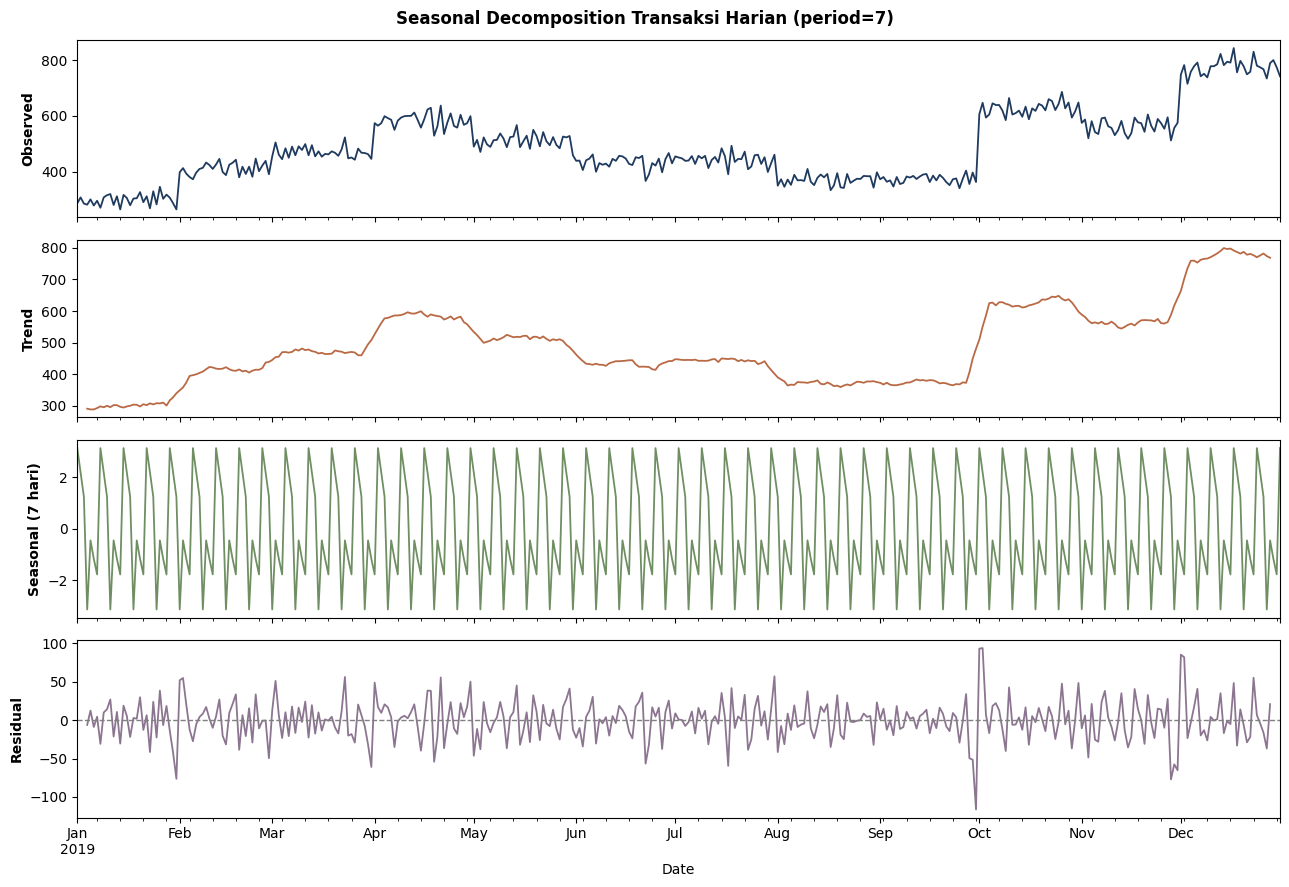

Amplitudo musiman mingguan : 6.2 transaksi
Rentang pergerakan trend   : 510.3 transaksi
Rasio trend : musiman      = 81.7 : 1


In [28]:
from statsmodels.tsa.seasonal import seasonal_decompose
import matplotlib.pyplot as plt

dekom = seasonal_decompose(daily['trx'], model='additive', period=7)

fig, ax = plt.subplots(4, 1, figsize=(13, 9), sharex=True)
for a, s, n, c in zip(ax, [dekom.observed, dekom.trend, dekom.seasonal, dekom.resid],
                      ['Observed', 'Trend', 'Seasonal (7 hari)', 'Residual'],
                      ['#1F3A5F', '#B96A45', '#6F8F63', '#8C7590']):
    s.plot(ax=a, color=c, lw=1.3); a.set_ylabel(n, fontweight='bold')
ax[3].axhline(0, color='grey', ls='--', lw=1)
fig.suptitle('Seasonal Decomposition Transaksi Harian (period=7)', fontweight='bold'); plt.tight_layout(); plt.show()

amp_musiman  = dekom.seasonal.max() - dekom.seasonal.min()
rentang_trend = dekom.trend.max() - dekom.trend.min()
print(f'Amplitudo musiman mingguan : {amp_musiman:.1f} transaksi')
print(f'Rentang pergerakan trend   : {rentang_trend:.1f} transaksi')
print(f'Rasio trend : musiman      = {rentang_trend / amp_musiman:.1f} : 1')

#### Interpretasi

1. Trend sangat dominan. Rentang pergerakan trend 510 transaksi, sedangkan amplitudo musiman mingguan hanya 6,2 transaksi. Rasionya sekitar 82 banding 1.
2. Komponen musiman 7 hari nyaris tidak ada artinya, dan sebagian besar pergerakan berasal dari perubahan tingkat penjualan antar bulan.
3. Konsekuensi untuk pemodelan. Model dengan komponen musiman mingguan tidak akan memberi keunggulan besar, sedangkan pola musiman yang sebenarnya berperan (bulanan atau tahunan) tidak bisa ditangkap oleh `period=7` dan belum bisa dipelajari dari hanya satu tahun data.

## H.3 Pola per hari dalam minggu dan per bulan

Efek musiman per hari (selisih dari rata-rata, satuan transaksi):
Senin    -1.8
Selasa    3.1
Rabu      2.2
Kamis     1.2
Jumat    -3.1
Sabtu    -0.5
Minggu   -1.2

Rata-rata transaksi per hari, per bulan:
Date
Jan    299.0
Feb    411.0
Mar    469.0
Apr    584.0
May    511.0
Jun    433.0
Jul    444.0
Aug    370.0
Sep    373.0
Oct    627.0
Nov    562.0
Dec    774.0


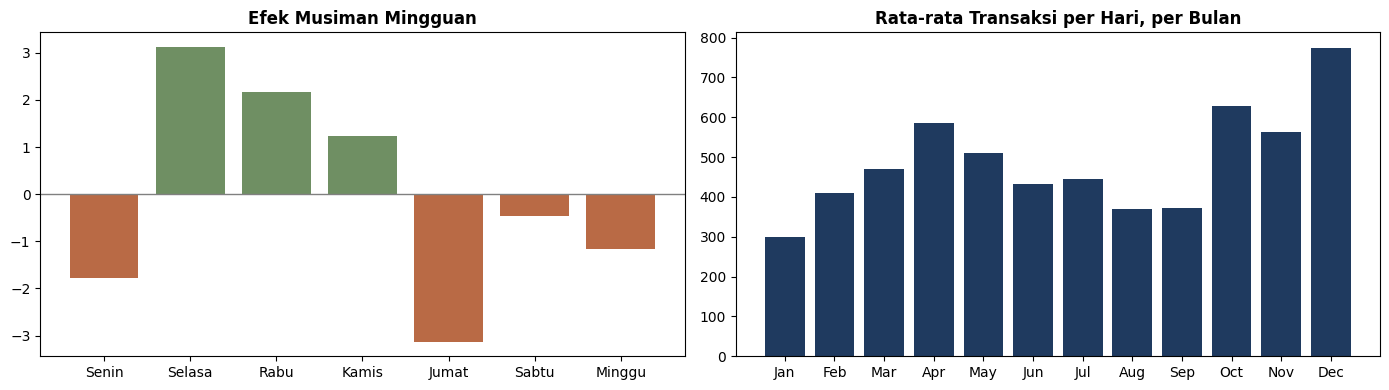

In [29]:
nama_hari = ['Senin', 'Selasa', 'Rabu', 'Kamis', 'Jumat', 'Sabtu', 'Minggu']
efek_hari = pd.Series(dekom.seasonal.values, index=daily.index).groupby(daily.index.dayofweek).mean()
efek_hari.index = nama_hari
print('Efek musiman per hari (selisih dari rata-rata, satuan transaksi):')
print(efek_hari.round(1).to_string())

# Rata-rata order per hari untuk tiap bulan (pola musiman tahunan)
bln = daily['trx'].resample('ME').mean()
print('\nRata-rata transaksi per hari, per bulan:')
print(bln.round(0).rename(lambda x: x.strftime('%b')).to_string())

fig, ax = plt.subplots(1, 2, figsize=(14, 4))
ax[0].bar(efek_hari.index, efek_hari.values, color=['#6F8F63' if v >= 0 else '#B96A45' for v in efek_hari])
ax[0].axhline(0, color='grey', lw=1); ax[0].set_title('Efek Musiman Mingguan', fontweight='bold')
ax[1].bar(bln.index.strftime('%b'), bln.values, color='#1F3A5F'); ax[1].set_title('Rata-rata Transaksi per Hari, per Bulan', fontweight='bold')
plt.tight_layout(); plt.show()

#### Interpretasi

1. Efek per hari dalam minggu hanya berkisar antara -3,1 (Jumat) dan +3,1 (Selasa) transaksi, atau sekitar 0,6% dari rata-rata harian. Praktis tidak ada pola mingguan.
2. Pola bulanan jauh lebih kuat. Rata-rata transaksi per hari 299 (Januari), 411, 469, 584 (April), 511, 433, 444, 370 (Agustus), 373, 627 (Oktober), 562, 774 (Desember).
3. Ada tiga puncak (April, Oktober, Desember) dan tiga lembah (Januari, Agustus dan September). Desember 2,6 kali Januari.
4. Karena data baru satu tahun, tidak bisa dipastikan apakah pola ini musiman tahunan yang akan berulang atau sekadar naik turun tahun 2019 saja. Pembuktiannya butuh minimal dua tahun data.

## H.4 Uji stasioneritas (ADF)

In [31]:
from statsmodels.tsa.stattools import adfuller

def uji_adf(series, nama):
    stat, p = adfuller(series.dropna())[:2]
    status = 'STASIONER' if p <= 0.05 else 'TIDAK stasioner'
    print(f'{nama:<32} ADF = {stat:>7.3f} | p-value = {p:.4f} -> {status}')
    return p

for kol in ['trx', 'visitor']:
    print(f'--- {kol} ---')
    p0 = uji_adf(daily[kol], 'Data asli')
    p1 = uji_adf(daily[kol].diff(), 'Differencing 1x')
    d_opt = 0 if p0 <= 0.05 else 1
    print(f'=> d = {d_opt}\n')

--- trx ---
Data asli                        ADF =  -1.131 | p-value = 0.7025 -> TIDAK stasioner
Differencing 1x                  ADF = -14.808 | p-value = 0.0000 -> STASIONER
=> d = 1

--- visitor ---
Data asli                        ADF =  -1.132 | p-value = 0.7023 -> TIDAK stasioner
Differencing 1x                  ADF = -14.793 | p-value = 0.0000 -> STASIONER
=> d = 1



/tmp/ipykernel_1300/1691852337.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, p = adfuller(series.dropna())[:2]
/tmp/ipykernel_1300/1691852337.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store and autolag arguments. In release 0.16 or after July 2027, whichever is later, the default behavior will switch to always returning an ADFullerResult. Set result_object=True to switch now, or result_object=False to keep the current behavior and silence this warning.
  stat, p = adfuller(series.dropna())[:2]
/tmp/ipykernel_1300/1691852337.py:4: FutureWarning: adfuller currently returns a plain tuple whose length depends on the store a

#### Interpretasi

1. Data asli tidak stasioner (p-value 0,7025 untuk transaksi dan 0,7023 untuk visitor, jauh di atas 0,05). Setelah differencing 1 kali menjadi stasioner (p-value 0,0000), jadi d = 1 untuk komponen ARIMA.
2. Hasil ini konsisten dengan temuan decomposition. Rata-rata deret bergeser antar bulan (trend dominan), sehingga model harus bekerja pada selisih antar hari, bukan pada level.

# I. Model Forecasting

**P7.** Bangun minimal 2 model forecasting untuk jumlah visitor dan jumlah transaksi 1 bulan ke depan dengan data harian, lalu pilih model terbaik berdasarkan MAPE terkecil.

**Desain evaluasi.** Karena target akhir adalah forecast 1 bulan, data uji dibuat **30 hari terakhir** (2 sampai 31 Desember 2019), sisanya (1 Januari sampai 1 Desember) untuk training. Split selalu berurutan waktu, tidak diacak. Model yang diuji: **SARIMA** (grid search order berdasar AIC), beberapa varian **ETS / Holt-Winters**, dan **baseline naif** ("30 hari ke depan = 7 hari terakhir diulang") sebagai pembanding, bukan kandidat model final.

## I.1 Train-test split

In [32]:
H = 30        # panjang periode uji dan horizon forecast (hari)

def split(series, h=H):
    y = series.astype(float)
    return y[:-h], y[-h:]

train_trx, test_trx = split(daily['trx'])
train_vis, test_vis = split(daily['visitor'])
print(f'Train: {train_trx.index.min().date()} s/d {train_trx.index.max().date()} ({len(train_trx)} hari)')
print(f'Test : {test_trx.index.min().date()} s/d {test_trx.index.max().date()} ({len(test_trx)} hari)')

Train: 2019-01-01 s/d 2019-12-01 (335 hari)
Test : 2019-12-02 s/d 2019-12-31 (30 hari)


## I.2 Fungsi metrik dan pembangun model

In [38]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters import ExponentialSmoothing
import numpy as np
import pandas as pd

def hitung_metrik(aktual, prediksi):
    a = np.asarray(aktual, dtype=float); f = np.asarray(prediksi, dtype=float)
    return {'MAE': np.mean(np.abs(a - f)),
            'RMSE': np.sqrt(np.mean((a - f) ** 2)),
            'MAPE': np.mean(np.abs((a - f) / a)) * 100,
            'Bias': np.mean(f - a)}     # rata-rata (prediksi - aktual), negatif = model cenderung under-forecast

kandidat_order    = [(1,1,1), (2,1,1), (1,1,2), (0,1,1), (1,0,1), (2,1,2)]
kandidat_seasonal = [(1,1,1,7), (1,0,1,7), (0,1,1,7)]

spesifikasi_ets = {
    'ETS Simple (SES)':         dict(trend=None, seasonal=None),
    'ETS Holt (trend)':         dict(trend='add', seasonal=None),
    'ETS Holt damped':          dict(trend='add', seasonal=None, damped_trend=True),
    'ETS Holt-Winters (m=7)':   dict(trend='add', seasonal='add', seasonal_periods=7),
    'ETS Holt-Winters damped':  dict(trend='add', seasonal='add', seasonal_periods=7, damped_trend=True),
}

def cari_sarima(train):
    # Grid search manual: pilih kombinasi dengan AIC terkecil di data train
    hasil = []
    for o in kandidat_order:
        for s in kandidat_seasonal:
            try:
                m = SARIMAX(train, order=o, seasonal_order=s,
                            enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
                hasil.append({'order': o, 'seasonal_order': s, 'aic': m.aic})
            except Exception:
                pass
    return pd.DataFrame(hasil).sort_values('aic').reset_index(drop=True)

def evaluasi_semua(train, test):
    grid = cari_sarima(train)
    o, s = grid.loc[0, 'order'], grid.loc[0, 'seasonal_order']
    nama_sarima = f'SARIMA{o}x{s}'
    preds = {nama_sarima: SARIMAX(train, order=o, seasonal_order=s,
                                  enforce_stationarity=False, enforce_invertibility=False).fit(disp=False).forecast(len(test))}
    for nama, spec in spesifikasi_ets.items():
        preds[nama] = ExponentialSmoothing(train, initialization_method='estimated', **spec).fit().forecast(len(test))
    tabel = pd.DataFrame({n: hitung_metrik(test, p) for n, p in preds.items()}).T.sort_values('MAPE')
    naif = np.array([train.iloc[-7 + (i % 7)] for i in range(len(test))])       # baseline: ulang 7 hari terakhir
    tabel_naif = pd.DataFrame({'Baseline naif (ulang 7 hari)': hitung_metrik(test, naif)}).T
    return grid, preds, tabel, tabel_naif, (nama_sarima, o, s)

## I.3 Model untuk jumlah transaksi

In [37]:
grid_trx, preds_trx, eval_trx, naif_trx, cfg_trx = evaluasi_semua(train_trx, test_trx)
print('5 kombinasi SARIMA dengan AIC terkecil (data train):')
print(grid_trx.head(5).to_string())
print('\n' + '=' * 78)
print(f'  EVALUASI JUMLAH TRANSAKSI (test {len(test_trx)} hari)')
print('=' * 78)
print(pd.concat([eval_trx, naif_trx]).round(2).to_string())
best_trx = eval_trx.index[0]
print(f'\nModel terbaik (MAPE terkecil): {best_trx} | MAPE {eval_trx.loc[best_trx, "MAPE"]:.2f}%')

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


5 kombinasi SARIMA dengan AIC terkecil (data train):
       order seasonal_order          aic
0  (1, 1, 2)   (0, 1, 1, 7)  3194.436334
1  (2, 1, 2)   (0, 1, 1, 7)  3194.988358
2  (1, 1, 2)   (1, 1, 1, 7)  3196.168335
3  (0, 1, 1)   (0, 1, 1, 7)  3200.401364
4  (0, 1, 1)   (1, 1, 1, 7)  3202.194788

  EVALUASI JUMLAH TRANSAKSI (test 30 hari)
                                 MAE    RMSE   MAPE    Bias
SARIMA(1, 1, 2)x(0, 1, 1, 7)  101.24  105.26  12.95 -101.24
ETS Holt-Winters (m=7)        101.93  105.94  13.04 -101.93
ETS Holt (trend)              102.22  106.06  13.08 -102.22
ETS Holt-Winters damped       104.96  108.51  13.43 -104.96
ETS Simple (SES)              119.46  122.68  15.30 -119.46
ETS Holt damped               119.85  123.05  15.35 -119.85
Baseline naif (ulang 7 hari)  188.93  202.92  24.26 -188.93

Model terbaik (MAPE terkecil): SARIMA(1, 1, 2)x(0, 1, 1, 7) | MAPE 12.95%


#### Interpretasi

1. Grid search memilih SARIMA(1,1,2)(0,1,1,7) berdasarkan AIC terkecil di data train (3.194,44). Selisihnya kecil dengan kandidat kedua (3.195,07), jadi pemilihan order tidak terlalu sensitif.
2. Pada periode uji 30 hari, SARIMA terbaik dengan MAPE 12,95% (MAE 101 transaksi per hari). Holt-Winters (m=7) sangat dekat di 13,04%. Selisih 0,09 poin persentase itu terlalu kecil untuk disebut keunggulan yang meyakinkan. Kedua model secara praktis setara pada data ini.
3. Baseline naif (mengulang 7 hari terakhir) MAPE-nya 24,26%, jadi model SARIMA dan ETS memang menambah nilai pada horizon 30 hari.
4. Kolom Bias bernilai negatif dan besarnya sama dengan MAE untuk semua model. Artinya seluruh prediksi berada di bawah aktual pada hampir semua hari, dan kesalahannya sistematis, bukan acak. Penyebabnya terlihat di grafik berikutnya, tingkat penjualan naik tajam di awal Desember dan model yang dilatih sampai akhir November belum mengetahuinya.
5. Model terbaik tetap SARIMA(1,1,2)(0,1,1,7) berdasarkan MAPE terkecil sesuai kriteria assignment.

## I.4 Model untuk jumlah visitor (proksi)

In [39]:
grid_vis, preds_vis, eval_vis, naif_vis, cfg_vis = evaluasi_semua(train_vis, test_vis)
print('=' * 78)
print(f'  EVALUASI JUMLAH VISITOR PROKSI (test {len(test_vis)} hari)')
print('=' * 78)
print(pd.concat([eval_vis, naif_vis]).round(2).to_string())
best_vis = eval_vis.index[0]
print(f'\nModel terbaik (MAPE terkecil): {best_vis} | MAPE {eval_vis.loc[best_vis, "MAPE"]:.2f}%')

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


  EVALUASI JUMLAH VISITOR PROKSI (test 30 hari)
                                 MAE    RMSE   MAPE    Bias
SARIMA(1, 1, 2)x(0, 1, 1, 7)   89.15   93.81  11.41  -89.15
ETS Holt-Winters (m=7)        101.23  105.23  12.97 -101.23
ETS Holt (trend)              101.53  105.37  13.01 -101.53
ETS Holt-Winters damped       104.11  107.65  13.34 -104.11
ETS Simple (SES)              118.76  121.98  15.23 -118.76
ETS Holt damped               119.17  122.36  15.28 -119.17
Baseline naif (ulang 7 hari)  188.50  202.59  24.24 -188.50

Model terbaik (MAPE terkecil): SARIMA(1, 1, 2)x(0, 1, 1, 7) | MAPE 11.41%


#### Interpretasi

1. Untuk visitor proksi, SARIMA(1,1,2)(0,1,1,7) juga terbaik dengan MAPE 11,41%, lalu Holt-Winters (m=7) 12,97%. Kesenjangan di sini lebih lebar (1,56 poin). Kemungkinan besar ini berasal dari selisih kecil antara dua deret yang memengaruhi hasil optimasi model, bukan karena visitor lebih mudah diprediksi.
2. Baseline naif kembali paling buruk (24,24%) dan bias semua model negatif, sama seperti pada transaksi.
3. Seperti dicatat di bagian H.1, hasil visitor tidak independen dari transaksi, jadi interpretasinya sama.

## I.5 Aktual vs prediksi pada periode uji

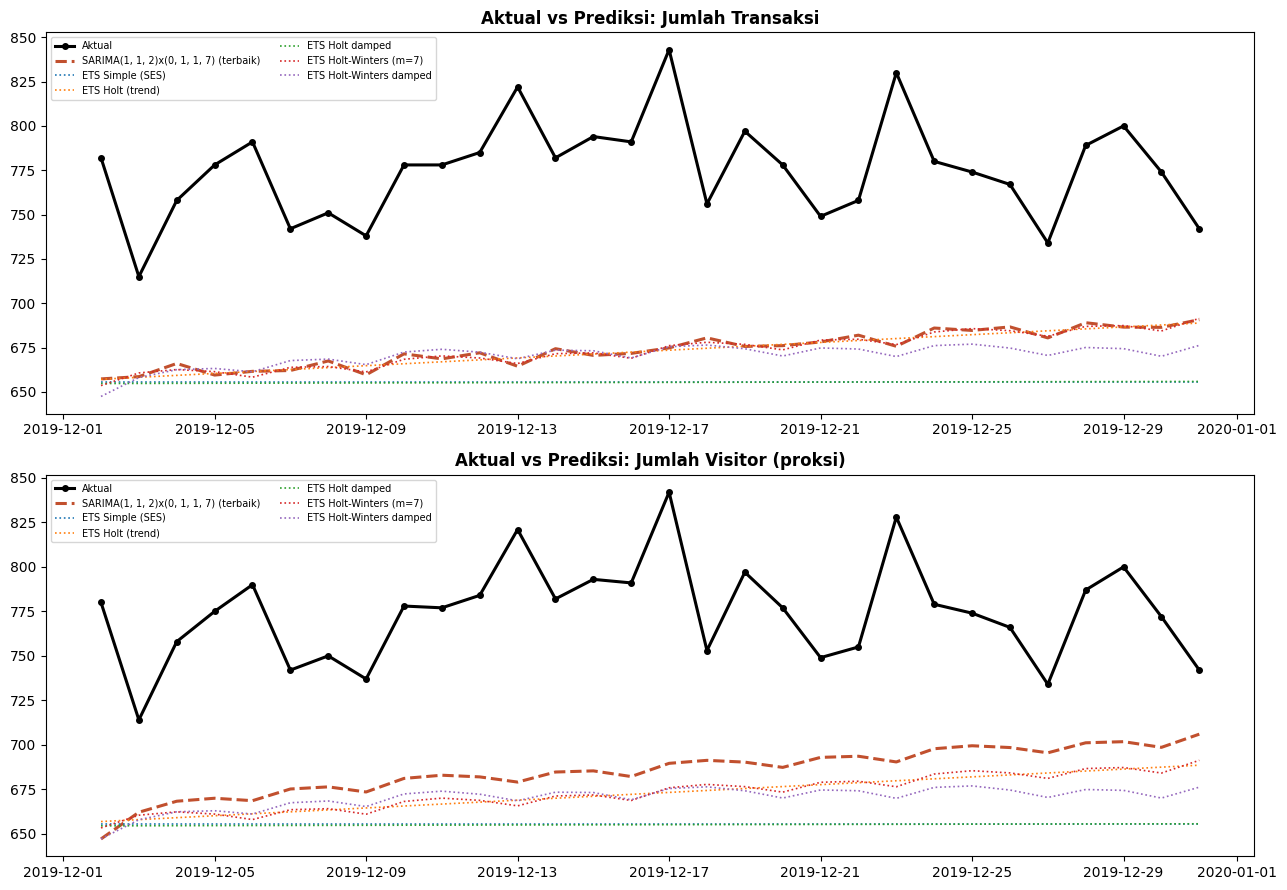

In [44]:
fig, ax = plt.subplots(2, 1, figsize=(13, 9))
for a, test, preds, best, judul in [(ax[0], test_trx, preds_trx, best_trx, 'Jumlah Transaksi'),
                                    (ax[1], test_vis, preds_vis, best_vis, 'Jumlah Visitor (proksi)')]:
    a.plot(test.index, test.values, 'o-', color='black', lw=2.2, ms=4, label='Aktual')
    for nama, p in preds.items():
        if nama == best: a.plot(test.index, p, '--', color='#C1502E', lw=2.2, label=f'{nama} (terbaik)')
        else:            a.plot(test.index, p, ':', lw=1.2, label=nama)
    a.set_title(f'Aktual vs Prediksi: {judul}', fontweight='bold'); a.legend(fontsize=7, ncol=2)
plt.tight_layout()
plt.show()

#### Interpretasi

1. Semua garis prediksi berada jauh di bawah garis aktual sepanjang Desember dan hampir sejajar satu sama lain (sekitar 655 sampai 690 transaksi, sementara aktual sekitar 715 sampai 843).
2. Model menangkap arah naik yang lembut, tetapi tidak menangkap lompatan tingkat di awal Desember. Pola naik turun harian di sekitar tingkat itu juga tidak tertangkap, wajar karena komponen musiman mingguan hampir tidak ada.
3. Jadi, MAPE 12,95% bukan hanya soal ketelitian model. Sebagian besar kesalahan berasal dari perubahan tingkat bulan yang tidak bisa diprediksi dari data harian sebelumnya.

## I.6 Robustness check: apakah pilihan model bergantung pada panjang periode uji?

Periode uji 30 hari jatuh di bulan Desember yang sedang naik tajam. Untuk memastikan kesimpulan tidak kebetulan, model yang sama diuji ulang dengan periode uji 14 hari.

In [41]:
tr14, te14 = split(daily['trx'], 14)
_, _, eval14, naif14, _ = evaluasi_semua(tr14, te14)
print('EVALUASI TRANSAKSI, periode uji 14 hari:')
print(pd.concat([eval14, naif14]).round(2).to_string())

/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(
/usr/local/lib/python3.13/dist-packages/statsmodels/tsa/statespace/mlemodel.py:737: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


EVALUASI TRANSAKSI, periode uji 14 hari:
                                MAE   RMSE  MAPE   Bias
ETS Simple (SES)              47.95  52.63  6.29  46.51
ETS Holt damped               50.60  55.39  6.64  49.51
ETS Holt-Winters damped       52.97  57.75  6.95  51.86
ETS Holt (trend)              58.76  64.22  7.71  58.74
ETS Holt-Winters (m=7)        58.96  64.19  7.73  58.45
SARIMA(1, 1, 2)x(0, 1, 1, 7)  61.03  66.50  8.00  60.91
Baseline naif (ulang 7 hari)  35.00  45.59  4.59  25.86


#### Interpretasi

1. Kalau periode uji dipendekkan menjadi 14 hari, urutan berubah. Baseline naif justru terbaik (MAPE 4,59%), disusul SES (6,29%), dan SARIMA menjadi yang terburuk di antara model (8,00%).
2. Jadi, kesimpulan "SARIMA terbaik" hanya berlaku pada horizon 30 hari. Pada horizon pendek dan tingkat penjualan yang sudah stabil, aturan sederhana seperti "sama dengan minggu lalu" sudah sangat sulit dikalahkan.
3. Pelajaran praktisnya, model yang lebih kompleks tidak otomatis lebih baik. Pemilihan model harus mengikuti horizon yang benar-benar dibutuhkan bisnis, dan baseline wajib dipakai sebagai pembanding.

## I.7 Forecast 1 bulan ke depan (Januari 2020)

In [42]:
# Refit model terbaik pada SELURUH data (365 hari), lalu ramalkan 31 hari (1-31 Januari 2020)
H_FC = 31
idx_fc = pd.date_range(daily.index.max() + pd.Timedelta(days=1), periods=H_FC, freq='D')

def forecast_final(series, nama_best, cfg):
    y = series.astype(float)
    if nama_best.startswith('SARIMA'):
        res = SARIMAX(y, order=cfg[1], seasonal_order=cfg[2],
                      enforce_stationarity=False, enforce_invertibility=False).fit(disp=False)
        fc = res.get_forecast(H_FC)
        return pd.DataFrame({'forecast': fc.predicted_mean.values,
                             'lower': fc.conf_int().iloc[:, 0].values,
                             'upper': fc.conf_int().iloc[:, 1].values}, index=idx_fc)
    res = ExponentialSmoothing(y, initialization_method='estimated', **spesifikasi_ets[nama_best]).fit()
    return pd.DataFrame({'forecast': res.forecast(H_FC).values}, index=idx_fc)

fc_trx = forecast_final(daily['trx'], best_trx, cfg_trx)
fc_vis = forecast_final(daily['visitor'], best_vis, cfg_vis)

print(f'Model final transaksi: {best_trx}')
print(fc_trx.round(0).head(7).to_string())
print(f'\nRata-rata forecast Januari 2020 : {fc_trx["forecast"].mean():.0f} transaksi/hari | total {fc_trx["forecast"].sum():,.0f}')
print(f'Rata-rata aktual Desember 2019  : {daily.loc["2019-12", "trx"].mean():.0f} transaksi/hari')
print(f'Rata-rata aktual Januari 2019   : {daily.loc["2019-01", "trx"].mean():.0f} transaksi/hari')
print(f'Rata-rata forecast visitor Jan  : {fc_vis["forecast"].mean():.0f}/hari')
print(f'Interval 95% transaksi hari ke-1 : {fc_trx["lower"].iloc[0]:.0f} - {fc_trx["upper"].iloc[0]:.0f}')
print(f'Interval 95% transaksi hari ke-31: {fc_trx["lower"].iloc[-1]:.0f} - {fc_trx["upper"].iloc[-1]:.0f}')
print(f'Selisih forecast vs rata-rata Jan 2019: {fc_trx["forecast"].mean() / daily.loc["2019-01", "trx"].mean():.2f}x')

Model final transaksi: SARIMA(1, 1, 2)x(0, 1, 1, 7)
            forecast  lower  upper
2020-01-01     765.0  694.0  835.0
2020-01-02     764.0  684.0  843.0
2020-01-03     760.0  672.0  849.0
2020-01-04     764.0  667.0  861.0
2020-01-05     765.0  660.0  870.0
2020-01-06     765.0  652.0  877.0
2020-01-07     770.0  650.0  890.0

Rata-rata forecast Januari 2020 : 780 transaksi/hari | total 24,168
Rata-rata aktual Desember 2019  : 774 transaksi/hari
Rata-rata aktual Januari 2019   : 299 transaksi/hari
Rata-rata forecast visitor Jan  : 779/hari
Interval 95% transaksi hari ke-1 : 694 - 835
Interval 95% transaksi hari ke-31: 553 - 1039
Selisih forecast vs rata-rata Jan 2019: 2.61x


#### Interpretasi

1. Model final SARIMA(1,1,2)(0,1,1,7) dilatih ulang pada seluruh 365 hari lalu meramal 1 sampai 31 Januari 2020. Hasilnya rata-rata 780 transaksi per hari (total 24.168), mendekati rata-rata Desember 2019 (774).
2. Interval prediksi 95% melebar dari 694 sampai 835 di hari pertama menjadi 553 sampai 1.039 di hari ke-31, jadi ketidakpastian membesar seiring jarak.
3. **Peringatan penting.** Pada Januari 2019, rata-rata transaksi hanya 299 per hari. Forecast Januari 2020 adalah 2,61 kali lipatnya. Model hanya melanjutkan tingkat Desember, karena dengan satu tahun data ia tidak bisa mempelajari bahwa bulan setelah puncak akhir tahun bisa turun. Jika pola 2019 berulang, forecast ini akan terlalu tinggi.
4. Dengan bias yang ditunjukkan di periode uji (model tertinggal saat tingkat naik), forecast ini paling aman dibaca sebagai skenario atas atau pengujian kapasitas, bukan target tunggal. Data 2018 atau data awal 2020 diperlukan untuk memastikan arah Januari.

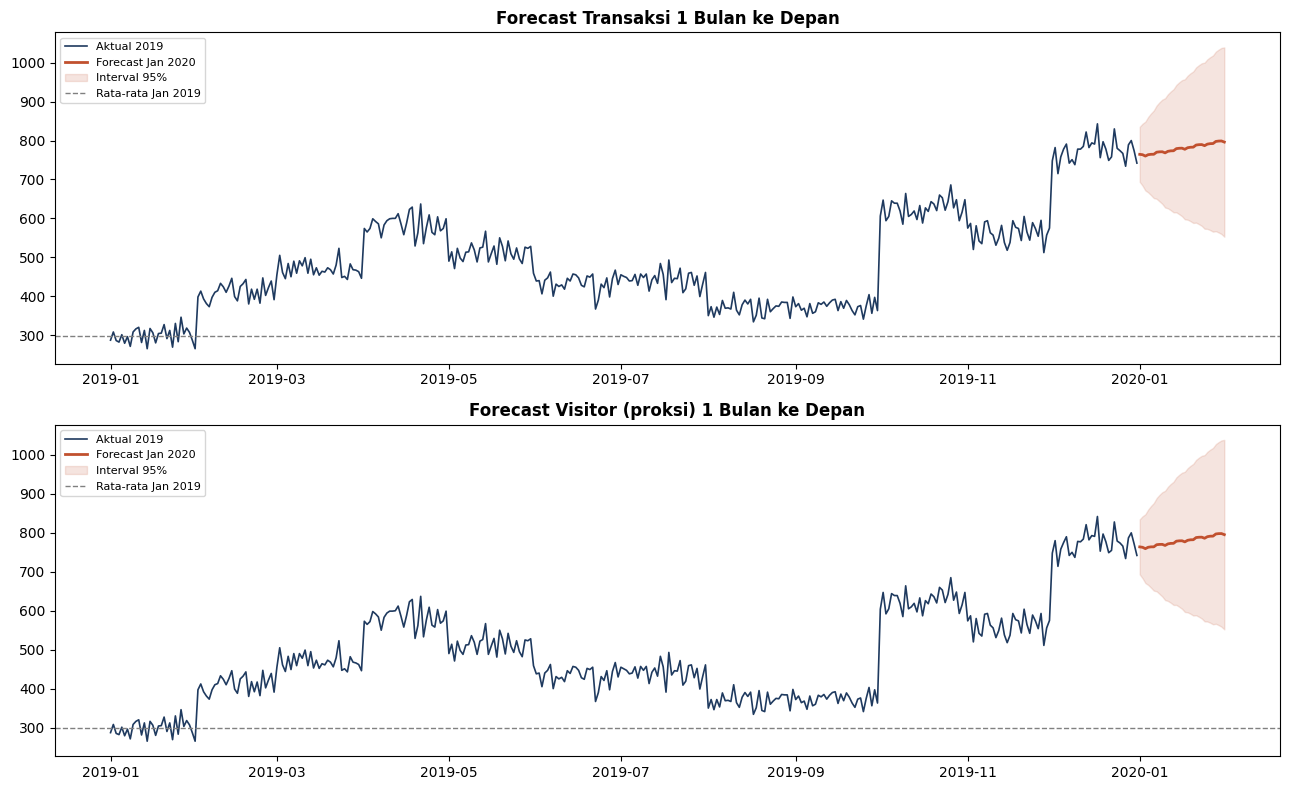

In [43]:
fig, ax = plt.subplots(2, 1, figsize=(13, 8))
for a, ser, fc, judul in [(ax[0], daily['trx'], fc_trx, 'Transaksi'), (ax[1], daily['visitor'], fc_vis, 'Visitor (proksi)')]:
    a.plot(ser.index, ser, color='#1F3A5F', lw=1.2, label='Aktual 2019')
    a.plot(fc.index, fc['forecast'], color='#C1502E', lw=2, label='Forecast Jan 2020')
    if 'lower' in fc: a.fill_between(fc.index, fc['lower'], fc['upper'], color='#C1502E', alpha=0.15, label='Interval 95%')
    # pembanding: pola Januari 2019 (level tahun lalu)
    a.axhline(ser.loc['2019-01'].mean(), color='grey', ls='--', lw=1, label='Rata-rata Jan 2019')
    a.set_title(f'Forecast {judul} 1 Bulan ke Depan', fontweight='bold'); a.legend(fontsize=8)
plt.tight_layout(); plt.show()

#### Interpretasi

1. Garis forecast (merah) berlanjut dari tingkat Desember, sedangkan garis putus-putus abu-abu (rata-rata Januari 2019) berada jauh di bawahnya. Jarak keduanya menunjukkan rentang ketidakpastian yang sebenarnya, jauh lebih lebar daripada pita interval 95% model.
2. Pita interval hanya mengukur ketidakpastian dalam asumsi model bahwa tingkat penjualan tetap. Ia tidak mencakup risiko perubahan tingkat (regime change) seperti yang terlihat pada Februari, April, Oktober, dan Desember.

# J. Rekomendasi Bisnis & Kesimpulan

**Rekomendasi berdasarkan hasil forecasting dan analisis (P7)**

1. **Gunakan forecast sebagai rentang, bukan angka tunggal.** Model memberi 780 transaksi per hari untuk Januari 2020, sedangkan Januari 2019 hanya 299. Untuk perencanaan, siapkan dua skenario. Skenario atas mengikuti model (sekitar 780 per hari, total sekitar 24.000 transaksi) dan skenario bawah mengikuti pola Januari tahun lalu (di kisaran 300 per hari). Rencana stok dan staf sebaiknya bisa naik turun di antara keduanya, bukan dikunci pada salah satu.
2. **Pantau realisasi mingguan dan lakukan forecast ulang tiap minggu.** Model mudah tertinggal saat tingkat penjualan bergeser (bias di periode uji sekitar 100 transaksi per hari). Dengan forecast bergulir, koreksi bisa dilakukan dalam beberapa hari, bukan sebulan.
3. **Fokuskan kampanye pada jam, bukan hari.** Order tersebar merata di semua hari (485 sampai 492 per hari), tetapi 40,1% order terjadi pada 11.00 sampai 13.59 dan 18.00 sampai 20.59. Pasang iklan, notifikasi, dan promo flash di jam itu, dan pastikan kapasitas customer service, server, dan pengiriman siap. Sekitar jam 03.00 sampai 04.59 adalah jendela yang paling aman untuk pemeliharaan sistem.
4. **Uji bundling ponsel dengan kabel pengisi yang sesuai.** Google Phone + USB-C, iPhone + Lightning, dan Vareebadd Phone + USB-C punya lift di atas 1. Bundling iPhone + Airpods dan Google Phone + Bose bisa dijadikan A/B test terbatas karena datanya lemah (lift di bawah 1). Rata-rata barang per order baru 1,17, jadi ruang untuk menaikkan nilai keranjang besar.
5. **Lindungi ketersediaan produk penggerak revenue.** Macbook Pro, iPhone, ThinkPad, dan Google Phone menyumbang sekitar 59% revenue tiga bulan terakhir. Kehabisan stok pada produk ini pada bulan puncak (Oktober dan Desember) langsung memukul GMV.
6. **Kurangi ketergantungan pada beberapa kota.** San Francisco menyumbang hampir seperempat GMV dan tiga kota teratas 53,3%. Nilai per order antar kota hampir sama, jadi pertumbuhan harus datang dari menambah order (akuisisi dan retensi di kota lain), bukan menaikkan keranjang per kota.
7. **Perbaiki data sebelum forecast berikutnya.** Kumpulkan data visitor asli (sesi web analytics) dan data minimal dua tahun. Tanpa itu, forecast visitor hanya mengulang forecast transaksi dan pola musiman tahunan tidak bisa dipastikan.

**Keterbatasan analisis**

1. Forecast berbasis 365 hari data dan tidak dapat mempelajari musiman tahunan.
2. Proksi visitor hampir identik dengan transaksi (korelasi 1,0000).
3. GMV tidak memperhitungkan diskon dan biaya lain karena kolomnya tidak ada.
4. Perbandingan model SARIMA dan Holt-Winters pada horizon 30 hari terlalu tipis (12,95% dan 13,04%) untuk menyebut satu model unggul secara meyakinkan.
5. Pilihan model terbaik berubah jika periode uji dipendekkan (baseline naif terbaik pada 14 hari).

**Kesimpulan**

1. Bisnis tumbuh dan sangat fluktuatif antar bulan. Pola bulanan (puncak April, Oktober, Desember) jauh lebih besar dari pola mingguan yang hampir tidak ada.
2. Aksi marketing yang paling terarah adalah berdasarkan jam (dua jendela rush hour) dan bundling ponsel dengan kabel pengisi, bukan berdasarkan hari atau kota.
3. Model forecasting berguna pada horizon pendek dan sebagai batas atas skenario, tetapi belum cukup dipercaya sebagai angka tunggal untuk Januari karena hanya ada data satu tahun dan tingkat penjualan berubah tiap bulan.